In [68]:
import jax
jax.config.update("jax_enable_x64", True)

# A quick introduction to modeling dynamical systems driven by partial differential equations

Consider a time-dependent function $u(t,x)$ representing the state of some underlying physical system. In many cases, this function is characterized as the solution of a partial differential equation

$$
\frac{\partial u}{\partial t} = Lu + f(x, u, \partial_{x} u, \partial_{xx}u, \dots),
$$

subject to some boundary conditions, where $L$ is a linear differential operator and $f$ is a (generally nonlinear) function of $u$ and possibly its spatial derivatives.

## Discretization of PDEs

Solving a time-dependent PDE numerically requires a choice of spatial discretization: the solution $u(t,x)$ is expressed either in a finite-dimensional basis, global (Fourier, Chebyshev polynomials) or local (Lagrange polynomials, B-splines), or via a spatial discretization scheme such as finite differences or finite volumes. Under any of these choices, the PDE reduces to an ODE over the discretized state $\mathbf{u}(t) \in \mathbb{R}^n$:

$$
\frac{d\mathbf{u}}{dt} = A\mathbf{u} + f(\mathbf{u}),
$$

where $A$ is the matrix representation of the discretized operator $L$, and the boundary conditions are typically absorbed into the definition of $\mathbf{u}$ and $A$. This reduction turns the problem of inferring unknowns in a PDE into inferring unknowns in an ODE — exactly the class of problem dynestyx is built to handle, letting us place priors over initial conditions and unknown parameters and run standard probabilistic-programming inference directly on the resulting finite-dimensional dynamical system.

Numerically, the ODE can be solved using either an explicit or an implicit time-marching scheme, such as the forward and backward Euler schemes:
$$
\begin{aligned}
\mathbf{u}^{n+1} &= \mathbf{u}^n + \Delta t\big( A \mathbf{u}^n + f(\mathbf{u}^n) \big) \quad &&\text{Explicit: the RHS depends only on } \mathbf{u}^n\\[4pt]
\mathbf{u}^{n+1} &= \mathbf{u}^n + \Delta t\big( A \mathbf{u}^{n+1} + f(\mathbf{u}^{n+1}) \big) \quad &&\text{Implicit: the RHS depends only on } \mathbf{u}^{n+1}\\[4pt]
\end{aligned}
$$
A single step of an explicit scheme is the cheapest to compute, but for stiff systems may require an unrealistically small $\Delta t$ to remain numerically stable. Implicit schemes remain stable at much larger step sizes, at the cost of a full nonlinear solve at each step. Implicit-explicit (IMEX) methods combine the advantages of both by splitting the right-hand side into an implicit part (often the linear operator $A$) and an explicit part (often the nonlinearity $f$); these are not yet supported in dynestyx.

# A first model: linear heat equation

As a first example, we consider the linear heat equation with zero Dirichlet boundary conditions:

$$
\begin{aligned}
&\frac{\partial u}{\partial t} = \nu\Delta u \quad && (x,t) \in (0, T) \times (0,1)\\
& u(t, 0) = u(t, 1) = 0 \quad && x \in \{0,1\}\\
& u(0, x)= u_0 \quad && x \in [0,1]
\end{aligned}
$$

where $\Delta := \frac{\partial^2 }{\partial x^2}$ is the one-dimensional Laplacian. Discretizing space on a uniform grid $x_i$ and writing $\mathbf{u}^t_i = u(t, x_i)$, the discrete Laplacian is

$$
\Delta \mathbf{u}^t_i = \frac{\mathbf{u}^t_{i+1} -2\mathbf{u}^t_{i} + \mathbf{u}^t_{i-1}}{h^2}.
$$

In matrix form this is $\Delta \mathbf{u} = A\mathbf{u}$, where, on the interior nodes (the boundary values are held fixed at zero by the Dirichlet condition), $A$ is the tridiagonal matrix

$$
A = \frac{1}{h^2}
\begin{pmatrix}
-2 & 1 & & & \\
1 & -2 & 1 & & \\
 & \ddots & \ddots & \ddots & \\
 & & 1 & -2 & 1 \\
 & & & 1 & -2
\end{pmatrix}.
$$

The dynamics are then given by the linear model

$$
\frac{d\mathbf{u}}{dt}(t) = \nu A \mathbf{u}(t).
$$

The initial condition is a smooth Gaussian bump multiplied by a sine factor to ensure compatibility with the zero Dirichlet boundary condition:

$$
u_0(x) = \exp\Big(-\frac{(x -\mu)^2}{0.5}\Big)\sin(\pi x).
$$

The bump's center $\mu$ is the unknown parameter we aim to recover.

In [69]:

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist

import dynestyx as dsx
from dynestyx import ContinuousTimeStateEvolution, DynamicalModel, LinearGaussianObservation
from dynestyx.inference.filter_configs import ContinuousTimeKFConfig
from dynestyx import Simulator, Filter
import diffrax as dfx

import jax.random as jr
from numpyro.infer import Predictive

from dynestyx import ODESimulator



In [70]:
# Discretization parametes
spatial_discretization = 2**6
obs_time = jnp.linspace(0, 1, 2**6)

In [71]:
# Building the discrete laplacian operator for the heat equation (interior nodes only)
nu = 1e-2  # diffusion coefficient
n = spatial_discretization
x_full = jnp.linspace(0, 1, n, endpoint=True)
h = x_full[1] - x_full[0]
x = x_full[1:-1]  # interior nodes; boundary values are fixed at 0 by the Dirichlet BC

n_interior = n - 2
A = (jnp.diag(-2.0 * jnp.ones(n_interior))
     + jnp.diag(jnp.ones(n_interior - 1), 1)
     + jnp.diag(jnp.ones(n_interior - 1), -1)) / h**2 * nu

# Initial condition parameter
mu_true = 0.5

In [72]:
# define the initial condition a function of mu and x.
initial_condition = lambda mu : jnp.exp(- (x - mu)**2/(2*0.1**2)) * jnp.sin(jnp.pi*x)
ic_noise = 1e-2 # the noise on the initial condition
obs_noise = 1e-2 # the noise on the observations


def heat_equation_model(mu=None, obs_times=None, obs_values=None, predict_times=None):
    mu = numpyro.sample("mu", dist.Uniform(0, 1), obs=mu)

    # Create the dynamical model with sampled mu
    dynamics = DynamicalModel(initial_condition= dist.Normal(initial_condition(mu), ic_noise).to_event(1),
     state_evolution = ContinuousTimeStateEvolution(
            drift=lambda x, u, t: A @ x,
        ),
        observation_model = LinearGaussianObservation(
            H=jnp.eye(n_interior), R=obs_noise**2 * jnp.eye(n_interior)
        ),
    )

    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, predict_times=predict_times)

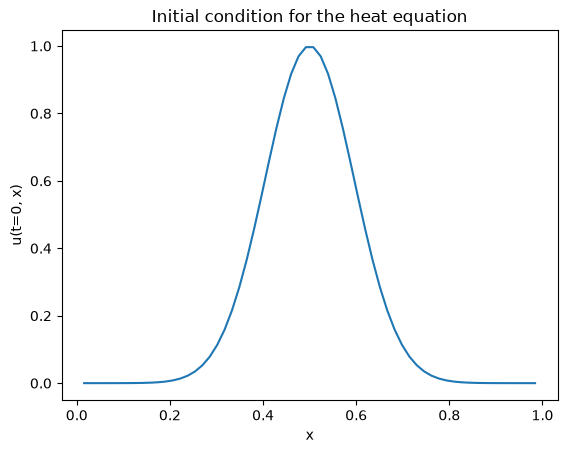

In [73]:
plt.plot(x, initial_condition(mu_true))
plt.title("Initial condition for the heat equation")
plt.xlabel("x")
plt.ylabel("u(t=0, x)")
plt.show()

## Generating the solution 

In [74]:
prng_key = jr.PRNGKey(0)
key, subkey = jr.split(prng_key)
predictive_model = Predictive(heat_equation_model, num_samples=1)

    
with ODESimulator(
    solver=dfx.ImplicitEuler(), # note the implcit solver is used here
    stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-5),
    dt0=1e-4,
    max_steps=10**6,
):
    pde_solution = predictive_model(predict_times=obs_time, obs_values=None, mu=mu_true, rng_key=subkey)

## Visualizing the solution

We plot the sampled realization both as a space-time heatmap and as an animation of $u(t, \cdot)$ over time. Since we solved for the interior nodes only, we pad the state back out with the (fixed, zero) Dirichlet boundary values before plotting.

In [75]:
u = pde_solution["f_states"][0, 0]  # (n_times, n_interior)
u_full = jnp.pad(u, ((0, 0), (1, 1)))  # add back the fixed zero boundary values

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Static heatmap
mesh = ax1.pcolormesh(x_full, obs_time, u_full, shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax1, label="u(t, x)")
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_title("Space-time solution of the heat equation")

# Animated line plot
line, = ax2.plot(x_full, u_full[0])
ax2.set_xlim(x_full[0], x_full[-1])
ax2.set_ylim(u_full.min(), u_full.max())
ax2.set_xlabel("x")
ax2.set_ylabel("u(t, x)")
time_label = ax2.set_title(f"t = {obs_time[0]:.3f}")

def update(frame):
    line.set_ydata(u_full[frame])
    time_label.set_text(f"t = {obs_time[frame]:.3f}")
    return line, time_label

anim = FuncAnimation(fig, update, frames=u_full.shape[0], interval=80)
plt.tight_layout()
plt.close(fig)
HTML(anim.to_jshtml())

# Inferring the initial condition using NUTS through the solver

We can now run NUTS directly under `ODESimulator`: NUTS backpropagates straight through the PDE solve ("unrolling"), the same
pattern used in the ODE tutorial.

In [81]:
from numpyro.infer import MCMC, NUTS
from numpyro.infer.reparam import LocScaleReparam
from numpyro.handlers import reparam

# `f_x_0` (dynestyx's internal initial-state site) is a 62-dim latent tightly coupled to
# the scalar `mu` via a narrow Gaussian (ic_noise). Sampled directly, this is a funnel:
# NUTS gets stuck with 0% acceptance regardless of warmup/samples. LocScaleReparam
# non-centers it (raw ~ N(0,1), f_x_0 = loc + ic_noise * raw), which fixes the geometry.
reparam_model = reparam(heat_equation_model, config={"f_x_0": LocScaleReparam(0)})

with ODESimulator(
    solver=dfx.ImplicitEuler(),
    stepsize_controller=dfx.PIDController(rtol=1e-5, atol=1e-5),
    dt0=1e-4,
    max_steps=10**6,
):
    nuts_kernel = NUTS(reparam_model, step_size=1e-4)
    mcmc = MCMC(nuts_kernel, num_warmup=75, num_samples=75)
    mcmc.run(
        jr.PRNGKey(1),
        obs_times=pde_solution["f_times"][0, 0],
        obs_values=pde_solution["f_observations"][0, 0],
    )
posterior = mcmc.get_samples()
print("Posterior mu mean:", float(jnp.mean(posterior["mu"])))
print("Posterior mu std:", float(jnp.std(posterior["mu"])))
print("True mu:", mu_true)

sample: 100%|██████████| 150/150 [16:43<00:00,  6.69s/it, 1023 steps of size 5.71e-04. acc. prob=0.87]

Posterior mu mean: 0.4998176615737267
Posterior mu std: 0.00016913852462442698
True mu: 0.5


# Inference with the continuous-time Kalman filter

Since the discretized `heat_equation` is a linear-Gaussian state-space model, we can a continuous-time Kalman to get the exact densities and use this within MCMC, as an alternative to running MCMC through the simulation. Further, this allows us to use the LTI module to efficiently solve the linear ODE.

We first define a new model that uses the LTI module present within dynestyx. 

In [77]:
def heat_equation(obs_times=None, obs_values=None, predict_times=None):
    mu = numpyro.sample("mu", dist.Uniform(0.0, 1.0))
    dynamics =dsx.LTI_continuous(
    A=A,                                  
    L=jnp.eye(x.shape[0])*0.0,                     # no diffusion: deterministic heat equation
    H=jnp.eye(x.shape[0]),                         # observe the full state 
    R=obs_noise**2 * jnp.eye(x.shape[0]),          # small observation noise 
    initial_mean=initial_condition(mu),            # initial condition mean
    initial_cov=ic_noise**2*jnp.eye(x.shape[0]),   # initial condition covariance
)
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )

In [78]:
data_predictive = Predictive(
    heat_equation,
    params={"mu": mu_true},
    num_samples=1,
    exclude_deterministic=False,
)

with Simulator(n_simulations=1):
    pde_solution = data_predictive(jr.PRNGKey(0), predict_times=obs_time)

u = pde_solution["f_states"][0, 0]
observations = pde_solution["f_observations"][0, 0]

In [79]:
u = pde_solution["f_states"][0, 0]  # (n_times, n_interior)
u_full = jnp.pad(u, ((0, 0), (1, 1)))  # add back the fixed zero boundary values

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Static heatmap
mesh = ax1.pcolormesh(x_full, obs_time, u_full, shading="auto", cmap="inferno")
fig.colorbar(mesh, ax=ax1, label="u(t, x)")
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_title("Space-time solution of the heat equation")

# Animated line plot
line, = ax2.plot(x_full, u_full[0])
ax2.set_xlim(x_full[0], x_full[-1])
ax2.set_ylim(u_full.min(), u_full.max())
ax2.set_xlabel("x")
ax2.set_ylabel("u(t, x)")
time_label = ax2.set_title(f"t = {obs_time[0]:.3f}")

def update(frame):
    line.set_ydata(u_full[frame])
    time_label.set_text(f"t = {obs_time[frame]:.3f}")
    return line, time_label

anim = FuncAnimation(fig, update, frames=u_full.shape[0], interval=80)
plt.tight_layout()
plt.close(fig)
HTML(anim.to_jshtml())

We now use the continuous time Kalman filter to obtain the marginal densities $p(\theta | y_{1:T})$ and run MCMC. In this case, the Kalman filter provides exact marginals.

In [80]:
def filtered_parameter_model():
    with Filter(
        filter_config=ContinuousTimeKFConfig( # the continuous-time Kalman filter.
            record_filtered_states_mean=True,
        )
    ):
        return heat_equation(obs_times=obs_time, obs_values=observations)


nuts = NUTS(filtered_parameter_model)
mcmc = MCMC(nuts, num_warmup=75, num_samples=75)
mcmc.run(jr.PRNGKey(2))
posterior = mcmc.get_samples()

sample: 100%|██████████| 150/150 [01:30<00:00,  1.65it/s, 3 steps of size 1.06e-01. acc. prob=0.98] 


In [67]:
print("Posterior mu mean:", float(jnp.mean(posterior["mu"])))
print("Posterior mu std:", float(jnp.std(posterior["mu"])))
print("True mu:", mu_true)

Posterior mu mean: 0.4999424984828169
Posterior mu std: 0.00044981278817763694
True mu: 0.5
